In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from voluntary_fixation.envs import SAVE_ROOT, TR, SUBJECT_IDS
from voluntary_fixation.dataset.bold_dataset import get_non_overlap_indices_for_concatenate_data

import matplotlib as mpl
mpl.rcParams['pdf.fonttype'] = 42  # TrueTypeフォントを埋め込む
mpl.rcParams['ps.fonttype'] = 42
mpl.rcParams['font.sans-serif'] = ['Arial','DejaVu Sans']
mpl.rcParams['font.family'] = 'sans-serif'
mpl.rcParams['axes.unicode_minus'] = False  # マイナス符号の化け防止

# plt.rcParams['font.family'] = 'Times New Roman' # font familyの設定
plt.rcParams['mathtext.fontset'] = 'stix' # math fontの設定
plt.rcParams["font.size"] = 25 # 全体のフォントサイズが変更されます。
plt.rcParams['xtick.labelsize'] = 23 # 軸だけ変更されます。
plt.rcParams['ytick.labelsize'] = 23 # 軸だけ変更されます

In [ ]:
frame_offset = 0
mask_offset = 0
delay = 0
gaze_shift_label = ['FIXA', 'PURS']
eyemovement_q = 0.9
saliency_q = 0.9
sampling_mode = 'segment'
saliency_label = 'avg_shift_norm'
sbj = '01'
iou_q = 0.5
saliency_TR_q = 0.7

iou_path = os.path.join('../../', SAVE_ROOT, 'mask', f'resolution{TR}-start{frame_offset}', 'iou',
                                f'sub-{sbj}.csv')

saliency_eyetrack_path = os.path.join('../../', SAVE_ROOT, 'behavior', f'saliency_eyetrack_TR{TR}',
                                        f'{sbj}-{"_".join(gaze_shift_label)}_q{eyemovement_q}-sal_q{saliency_q}.csv')
grand_quantiles = pd.read_csv(os.path.join('../../', SAVE_ROOT, 'behavior','grand_quantiles.csv'))
grand_quantiles_df = grand_quantiles.query(f'iou_q=={iou_q} and saliency_TR_q=={saliency_TR_q}')
print(saliency_eyetrack_path)

iou_df = pd.read_csv(iou_path)
saliency_eye_df = pd.read_csv(saliency_eyetrack_path)
non_overlap_train_indices, non_overlap_test_indices = get_non_overlap_indices_for_concatenate_data(sampling_mode, jupyter=True)

median_iou = grand_quantiles_df['iou_th'].item()
median_sal_upper = grand_quantiles_df['sal_upper_th'].item()
median_sal_lower = grand_quantiles_df['sal_lower_th'].item()
print(f'median_iou: {median_iou}, median_sal_upper: {median_sal_upper}, median_sal_lower: {median_sal_lower}')

ious = iou_df.iloc[non_overlap_test_indices]['iou'].values
sals = saliency_eye_df.iloc[non_overlap_test_indices][saliency_label].values
times = np.arange(len(ious))

../../../../results/voluntary_fixation/behavior/saliency_eyetrack_TR2/01-FIXA_PURS_q0.9-sal_q0.9.csv
median_iou: 0.31246855875, median_sal_upper: 1057.7329848865415, median_sal_lower: 424.8501357814248


/home/kazu/shared_response/figures/fig1_small/saliency_and_iou_time_course.pdf
/home/kazu/shared_response/figures/fig1_small/saliency_and_iou_time_course2.pdf


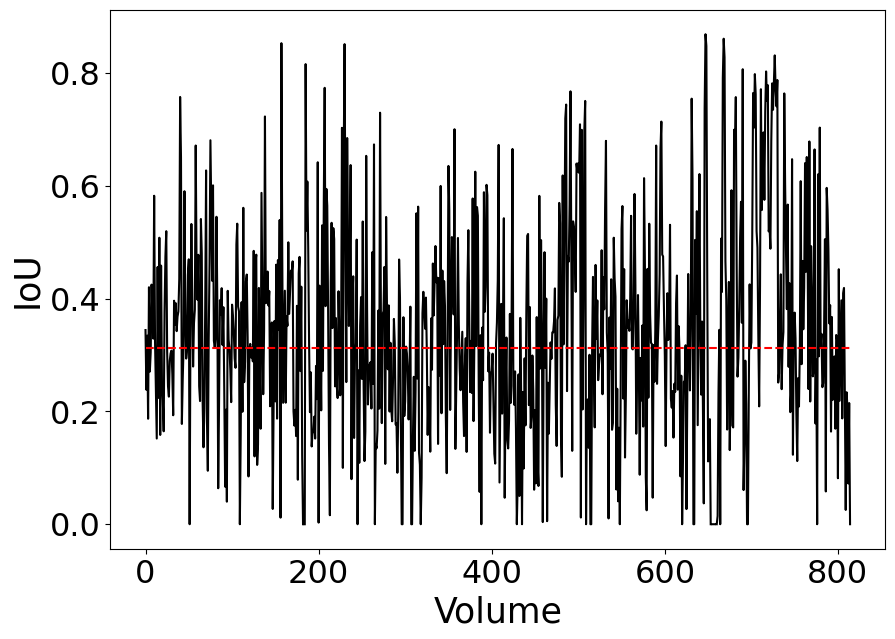

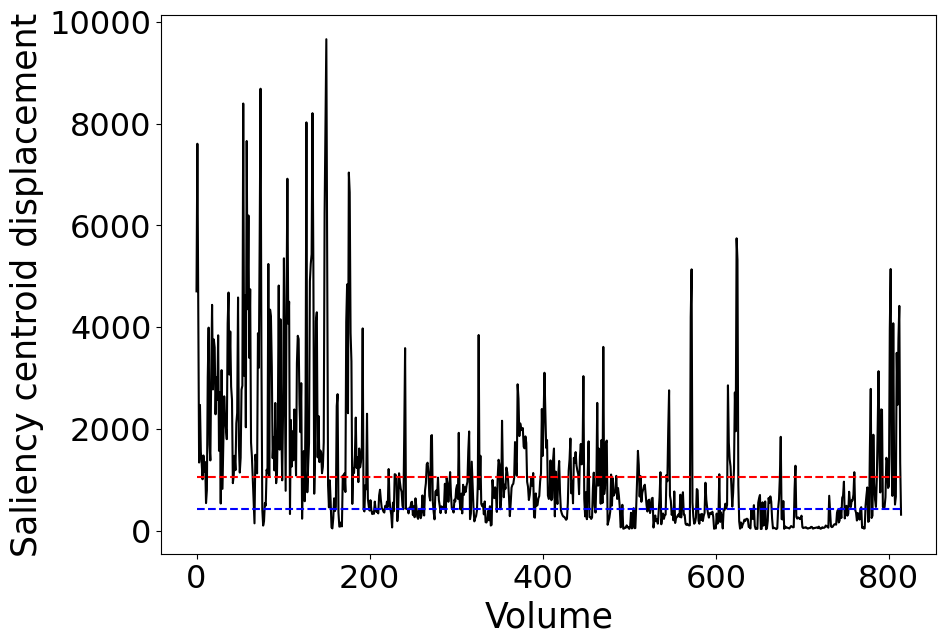

In [12]:


fig, ax = plt.subplots(nrows=1, figsize=(10, 7))
ax.plot(times, ious, 'k-')
ax.hlines(median_iou, times[0], times[-1], colors='r', linestyles='dashed')# , label='median in train data')
# ax[0].get_xaxis().set_visible(False)
# ax[1].get_xaxis().set_visible(False)
# ax[0].set_xlabel('Time [2 sec]')
# ax[1].set_xlabel('Time [2 sec]')
ax.set_xlabel('Volume')
ax.set_ylabel('IoU')
# ax[0].legend(bbox_to_anchor=(0, -0.1), loc='upper left', borderaxespad=0)
# ax[1].legend(bbox_to_anchor=(0, -0.1), loc='upper left', borderaxespad=0)
# plt.show()

savepath = os.path.join('figures', 'fig1_small', f'saliency_and_iou_time_course.pdf')
os.makedirs(os.path.dirname(savepath), exist_ok=True); plt.savefig(savepath, bbox_inches='tight', dpi=300)
print(savepath)

fig, ax = plt.subplots(nrows=1, figsize=(10, 7))
ax.plot(times, sals, 'k-')
ax.hlines(median_sal_upper, times[0], times[-1], colors='r', linestyles='dashed')#, label='median in train data')
ax.hlines(median_sal_lower, times[0], times[-1], colors='b', linestyles='dashed')
ax.set_xlabel('Volume')
ax.set_ylabel('Saliency centroid displacement')
savepath = os.path.join('figures', 'fig1_small', f'saliency_and_iou_time_course2.pdf')
os.makedirs(os.path.dirname(savepath), exist_ok=True); plt.savefig(savepath, bbox_inches='tight', dpi=300)
print(savepath)

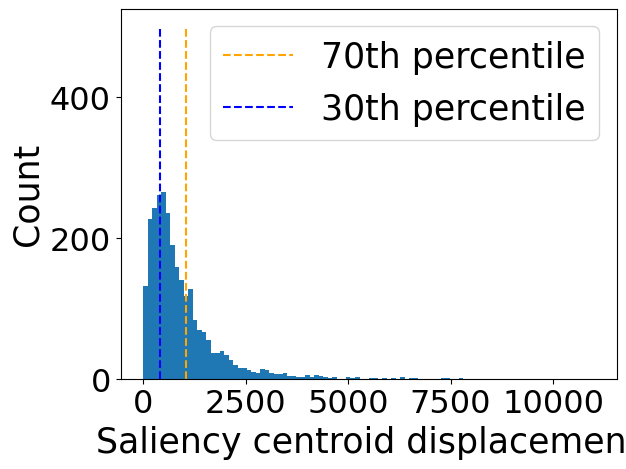

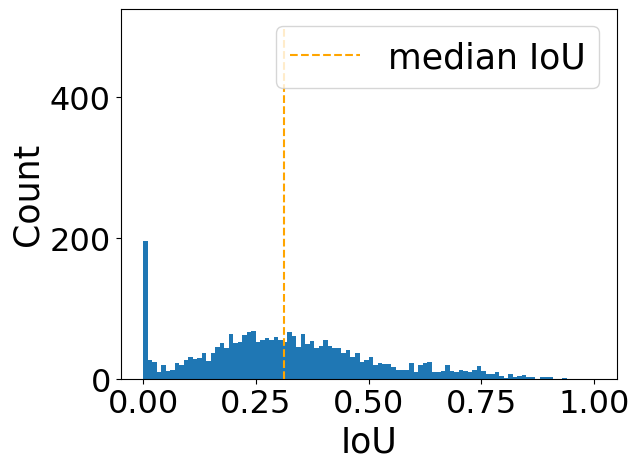

In [29]:
# SBJ 01
train_sals = saliency_eye_df.iloc[non_overlap_train_indices][saliency_label].values
plt.hist(train_sals, bins=100, range=(0, 11000))
plt.vlines(median_sal_upper, 0, 500, colors='orange', linestyles='dashed', label='70th percentile')
plt.vlines(median_sal_lower, 0, 500, colors='blue', linestyles='dashed', label='30th percentile')
plt.xlabel('Saliency centroid displacement')
plt.ylabel('Count')
plt.legend()
plt.show()
train_ious = iou_df.iloc[non_overlap_train_indices]['iou'].values
plt.hist(train_ious, bins=100, range=(0, 1))
plt.vlines(median_iou, 0, 500, colors='orange', linestyles='dashed', label=f'median IoU')
plt.xlabel('IoU')
plt.ylabel('Count')
plt.legend()
plt.show()

../../../../results/voluntary_fixation/behavior/saliency_eyetrack_TR2/01-FIXA_PURS_q0.9-sal_q0.9.csv
../../../../results/voluntary_fixation/behavior/saliency_eyetrack_TR2/02-FIXA_PURS_q0.9-sal_q0.9.csv
../../../../results/voluntary_fixation/behavior/saliency_eyetrack_TR2/03-FIXA_PURS_q0.9-sal_q0.9.csv
../../../../results/voluntary_fixation/behavior/saliency_eyetrack_TR2/04-FIXA_PURS_q0.9-sal_q0.9.csv
../../../../results/voluntary_fixation/behavior/saliency_eyetrack_TR2/06-FIXA_PURS_q0.9-sal_q0.9.csv
../../../../results/voluntary_fixation/behavior/saliency_eyetrack_TR2/10-FIXA_PURS_q0.9-sal_q0.9.csv
../../../../results/voluntary_fixation/behavior/saliency_eyetrack_TR2/14-FIXA_PURS_q0.9-sal_q0.9.csv
../../../../results/voluntary_fixation/behavior/saliency_eyetrack_TR2/15-FIXA_PURS_q0.9-sal_q0.9.csv
../../../../results/voluntary_fixation/behavior/saliency_eyetrack_TR2/16-FIXA_PURS_q0.9-sal_q0.9.csv
../../../../results/voluntary_fixation/behavior/saliency_eyetrack_TR2/17-FIXA_PURS_q0.9-sal

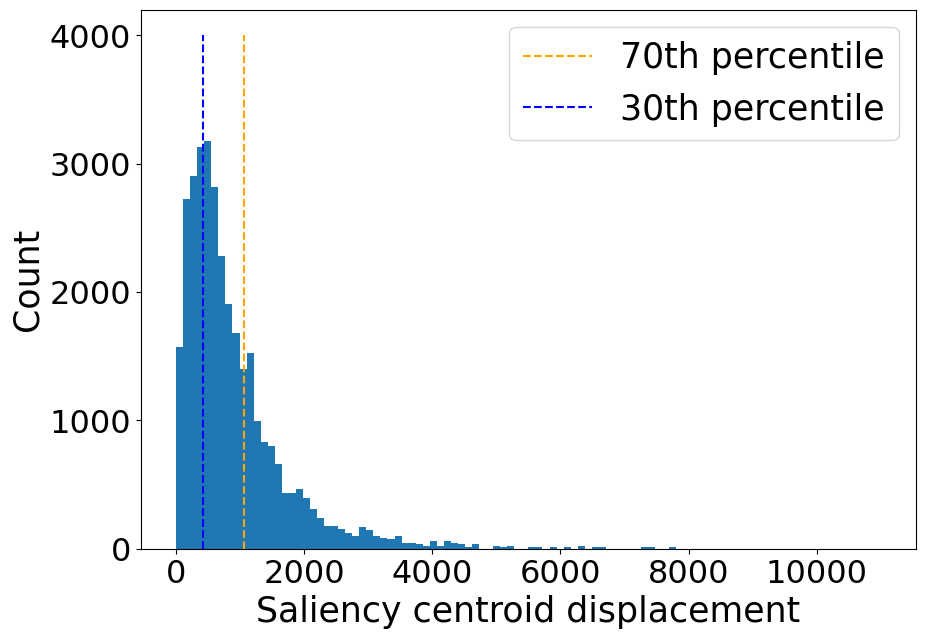

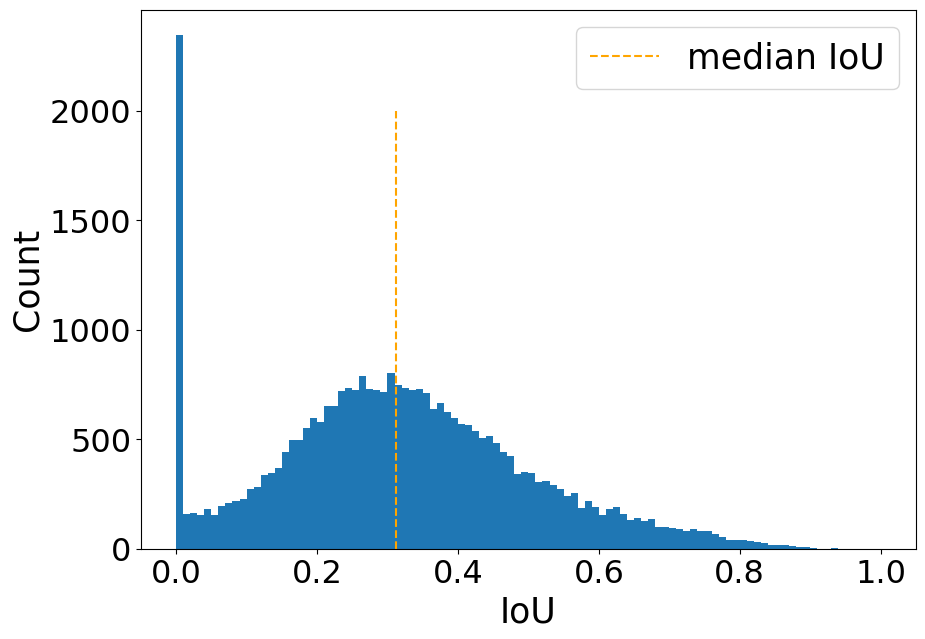

In [30]:
frame_offset = 0
mask_offset = 0
delay = 0
gaze_shift_label = ['FIXA', 'PURS']
eyemovement_q = 0.9
saliency_q = 0.9
sampling_mode = 'segment'
saliency_label = 'avg_shift_norm'
sbj = '01'
iou_q = 0.5
saliency_TR_q = 0.7

train_sals_all = []
train_ious_all = []
for sbj in SUBJECT_IDS:
    iou_path = os.path.join('../../', SAVE_ROOT, 'mask', f'resolution{TR}-start{frame_offset}', 'iou',
                                    f'sub-{sbj}.csv')

    saliency_eyetrack_path = os.path.join('../../', SAVE_ROOT, 'behavior', f'saliency_eyetrack_TR{TR}',
                                            f'{sbj}-{"_".join(gaze_shift_label)}_q{eyemovement_q}-sal_q{saliency_q}.csv')
    grand_quantiles = pd.read_csv(os.path.join('../../', SAVE_ROOT, 'behavior','grand_quantiles.csv'))
    grand_quantiles_df = grand_quantiles.query(f'iou_q=={iou_q} and saliency_TR_q=={saliency_TR_q}')
    print(saliency_eyetrack_path)

    iou_df = pd.read_csv(iou_path)
    saliency_eye_df = pd.read_csv(saliency_eyetrack_path)

    train_sals = saliency_eye_df.iloc[non_overlap_train_indices][saliency_label].values
    train_sals_all.extend(list(train_sals))
    train_ious = iou_df.iloc[non_overlap_train_indices]['iou'].values
    train_ious_all.extend(list(train_ious))

fig = plt.figure(figsize=(10, 7))
plt.hist(train_sals_all, bins=100, range=(0, 11000))
plt.vlines(median_sal_upper, 0, 4000, colors='orange', linestyles='dashed', label='70th percentile')
plt.vlines(median_sal_lower, 0, 4000, colors='blue', linestyles='dashed', label='30th percentile')
plt.xlabel('Saliency centroid displacement')
plt.ylabel('Count')
plt.legend()
plt.show()

fig = plt.figure(figsize=(10, 7))
plt.hist(train_ious_all, bins=100, range=(0, 1))
plt.vlines(median_iou, 0, 2000, colors='orange', linestyles='dashed', label=f'median IoU')
plt.xlabel('IoU')
plt.ylabel('Count')
plt.legend()
plt.show()
